# 02 - Hybrid Resampling & CTGAN (Window-Aware)

Notebook này điều phối pipeline cân bằng dữ liệu bằng cách sử dụng chiến lược **Mỏ neo (Anchor)** và **Sequence-CTGAN**.

### Quy trình:
1. **Anchor Sampling**: Giữ lại toàn bộ các cửa sổ Lớp 3 (Mỏ neo) và lấy mẫu các lớp 0, 1, 2 theo tỷ lệ tương ứng.
2. **Sequence Augmentation**: Sử dụng CTGAN để sinh thêm các cửa sổ giả cho Lớp 4 và 5 dựa trên các mẫu hạt giống (seeds).
3. **Validation**: Kiểm tra tính cân bằng dựa trên **Cửa sổ (Windows)** thay vì từng dòng đơn lẻ.

In [1]:
import os
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập Project Root
cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd] + list(cwd.parents) if (p / 'src').exists()), cwd)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.rl.data_balance.pipeline import ClassBalanceConfig, build_balanced_dataset_from_path
print("✅ Môi trường đã sẵn sàng.")

>>> LOADING PIPELINE VERSION 5.4 - TYPE ENFORCEMENT FIXED <<<
✅ Môi trường đã sẵn sàng.


In [2]:
# 1. ĐỊNH NGHĨA ĐƯỜNG DẪN
INPUT_PATH = PROJECT_ROOT / "data" / "processed" / "01_processed_features.parquet"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "02_balanced_training_data.parquet"
REPORT_PATH = PROJECT_ROOT / "reports" / "data_balance" / "balance_report.json"
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

# 2. CẤU HÌNH CHIẾN LƯỢC CÂN BẰNG ULTIMATE (DIVERSITY FOCUS)
config = ClassBalanceConfig(
    anchor_class=3,               # Mỏ neo: Lớp 3
    majority_multipliers={
        0: 4.0,                   # Tăng mạnh để đa dạng hóa kịch bản
        1: 5.0,                   
        2: 4.0                    
    },
    majority_cap=250000,          # Nâng giới hạn lên 250k mẫu
    synthetic_rows_class4=30000,  # Sinh thêm 30k cửa sổ Lớp 4
    synthetic_rows_class5=22000,  # Sinh thêm 22k cửa sổ Lớp 5
    use_ctgan=True,               
    output_path=str(OUTPUT_PATH),
    report_path=str(REPORT_PATH)
)

print(f"🚀 Chiến lược: Dùng Lớp {config.anchor_class} làm mỏ neo (Ultimate Diversity).")
print(f"🎯 Mục tiêu: Sinh {config.synthetic_rows_class4} (C4) và {config.synthetic_rows_class5} (C5) cửa sổ mới.")

🚀 Chiến lược: Dùng Lớp 3 làm mỏ neo (Ultimate Diversity).
🎯 Mục tiêu: Sinh 30000 (C4) và 22000 (C5) cửa sổ mới.


In [3]:
import time
start_time = time.time()

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"❌ Không tìm thấy file đầu vào tại: {INPUT_PATH}")

print("⏳ Đang thực hiện cân bằng dữ liệu (quá trình này mất khoảng 10-15 phút do sử dụng CTGAN)...\n")

balanced_df, report = build_balanced_dataset_from_path(
    input_path=INPUT_PATH,
    output_path=OUTPUT_PATH,
    config=config
)

elapsed = time.time() - start_time
print(f"\n✅ Hoàn thành trong {elapsed/60:.2f} phút!")
print(f"📊 Kích thước tập dữ liệu: {balanced_df.shape}")
print(f"💾 Đã lưu tại: {OUTPUT_PATH}")

⏳ Đang thực hiện cân bằng dữ liệu (quá trình này mất khoảng 10-15 phút do sử dụng CTGAN)...



⚠️  Class 5: Giới hạn từ 22000 xuống 7770 windows (chỉ có 259 seeds × 30 lần tối đa/seed)
🧬 Reality-based Augmenting Class 5: 259 seeds -> 7770 windows
🧬 Reality-based Augmenting Class 4: 2367 seeds -> 30000 windows
⚓ Stage 2 Smart-Filtering: Analyzing 2117695 windows...
🧠 Hybrid-Filtering Class 0: 652873 -> 205464
🧠 Hybrid-Filtering Class 1: 953849 -> 250000
🧠 Hybrid-Filtering Class 2: 456981 -> 205464

✅ Hoàn thành trong 7.18 phút!
📊 Kích thước tập dữ liệu: (9750832, 22)
💾 Đã lưu tại: /workspace/ai-core/data/processed/02_balanced_training_data.parquet


In [4]:
# KIỂM CHỨNG THEO CỬA SỔ (WINDOW-BASED VALIDATION)
print("🔍 Đang kiểm tra tính nhất quán của dữ liệu...")

# 1. Thống kê theo Window (Chỉ tính nhãn cuối cùng của mỗi segment)
window_stats = balanced_df.groupby('segment_key')['congestion_level'].last().value_counts().sort_index()

# 2. Kiểm tra tính liên tục (Mỗi segment phải có đúng 13 dòng)
seq_lengths = balanced_df.groupby('segment_key').size()
is_continuous = (seq_lengths == 13).all()

print("\n--- THỐNG KÊ THEO CỬA SỔ (WINDOWS) ---")
for cls, count in window_stats.items():
    source = "Synthetic" if cls >= 4 else "Real"
    print(f"Lớp {cls}: {count:>7} cửa sổ ({source})")

print(f"\nKiểm tra tính liên tục (13 bước/cửa sổ): {'✅ ĐẠT' if is_continuous else '❌ LỖI'}")
if not is_continuous:
    print(f"Cửa sổ không hợp lệ: {sum(seq_lengths != 13)}")

🔍 Đang kiểm tra tính nhất quán của dữ liệu...

--- THỐNG KÊ THEO CỬA SỔ (WINDOWS) ---
Lớp 0:  205464 cửa sổ (Real)
Lớp 1:  250000 cửa sổ (Real)
Lớp 2:  205464 cửa sổ (Real)
Lớp 3:   51366 cửa sổ (Real)
Lớp 4:   30000 cửa sổ (Synthetic)
Lớp 5:    7770 cửa sổ (Synthetic)

Kiểm tra tính liên tục (13 bước/cửa sổ): ✅ ĐẠT


/tmp/ipykernel_10648/97310841.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=after.index, y=after.values, palette=colors)


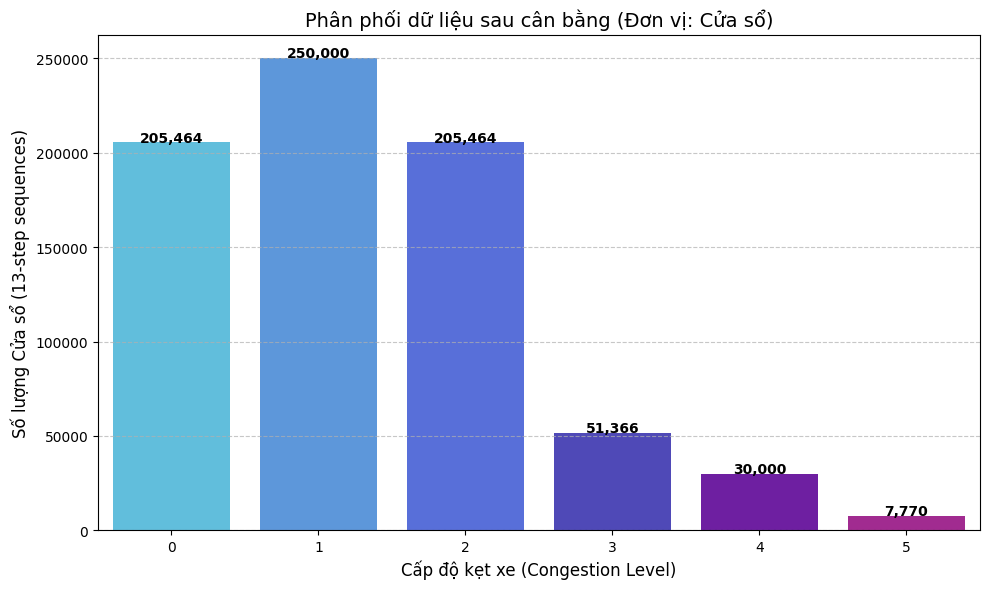

In [5]:
# TRỰC QUAN HÓA PHÂN PHỐI
if 'report' in locals():
    after_data = report.after_counts
    
    if after_data:
        after = pd.Series(after_data).sort_index()
        
        plt.figure(figsize=(10, 6))
        colors = ['#4CC9F0', '#4895EF', '#4361EE', '#3F37C9', '#7209B7', '#B5179E']
        sns.barplot(x=after.index, y=after.values, palette=colors)
        
        plt.title('Phân phối dữ liệu sau cân bằng (Đơn vị: Cửa sổ)', fontsize=14)
        plt.xlabel('Cấp độ kẹt xe (Congestion Level)', fontsize=12)
        plt.ylabel('Số lượng Cửa sổ (13-step sequences)', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Thêm con số trên đầu cột
        for i, v in enumerate(after.values):
            plt.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
            
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Không tìm thấy dữ liệu trong báo cáo.")

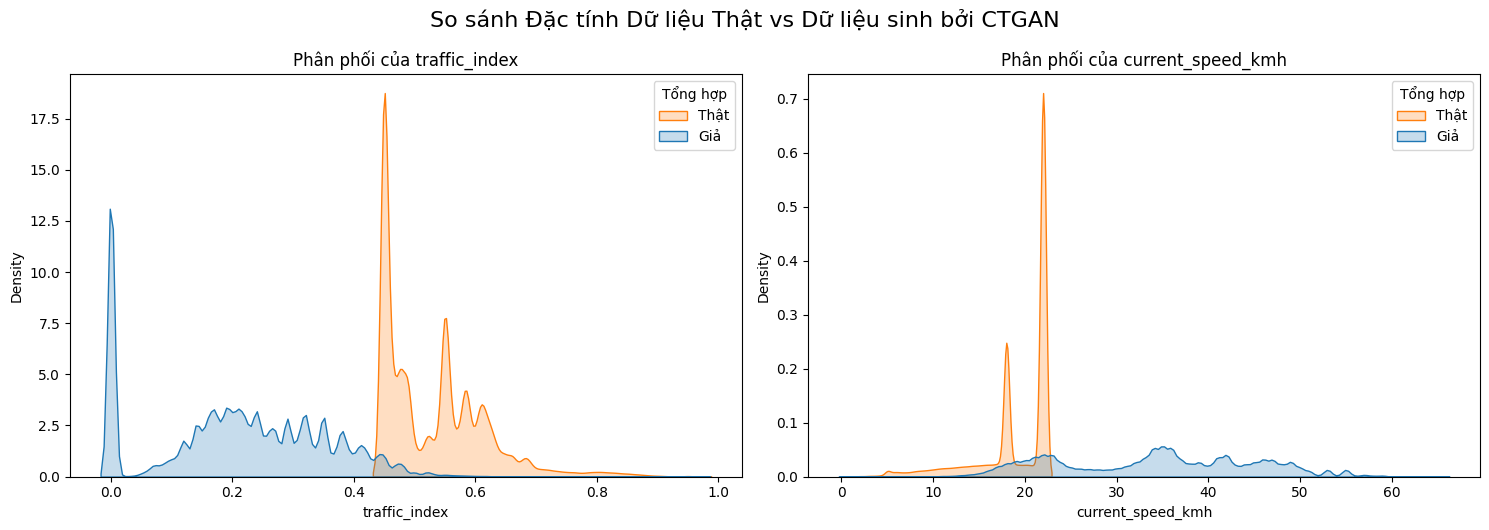

: 

In [ ]:
# KIỂM CHỨNG CHẤT LƯỢNG DỮ LIỆU TỔNG HỢP (KDE PLOT)
df_viz = balanced_df.copy()
df_viz['is_synthetic'] = df_viz['synthetic_flag'].fillna(0).astype(int)

features_to_check = ['traffic_index', 'current_speed_kmh']
fig, ax = plt.subplots(1, len(features_to_check), figsize=(15, 5))

for i, feat in enumerate(features_to_check):
    sns.kdeplot(data=df_viz, x=feat, hue='is_synthetic', common_norm=False, ax=ax[i], fill=True)
    ax[i].set_title(f'Phân phối của {feat}')
    ax[i].legend(title='Tổng hợp', labels=['Thật', 'Giả'])

plt.tight_layout()
plt.suptitle('So sánh Đặc tính Dữ liệu Thật vs Dữ liệu sinh bởi CTGAN', fontsize=16, y=1.05)
plt.show()